# SS_01 - Skull Stripping con HD-BET

**Pipeline SS (Skull Stripping)** - Notebook 1 de 6

Este notebook aplica skull-stripping con HD-BET a:
- 671 imágenes UPENN (unstripped) desde `Dataset/images_structural_unstripped/`
- 51 imágenes UPEN externos (ya stripped) desde `Dataset/images_structural_stripped/` (UPEN-GBM-00631 a 00681)

Todas las imágenes procesadas se guardan en `SS_PIPELINE/stripped_images/`

**Importante:** Este notebook no modifica ninguna carpeta ni notebook del pipeline original.

**Prerequisito:** GPU T4 activa en Colab (Entorno de ejecución → Cambiar tipo de entorno → T4 GPU)

In [ ]:
# CELDA 1 - Instalacion de dependencias
!pip install hd-bet -q

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 212.9/212.9 kB 18.2 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Preparing metadata (setup.py) ... done
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.0/77.0 kB 9.9 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 5.1 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.1/63.1 kB 8.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.6/52.6 MB 

In [ ]:
# CELDA 2 - Montar Google Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# CELDA 3 - Restaurar pesos HD-BET desde Drive
import shutil
from pathlib import Path

hdbet_drive = Path('/content/drive/MyDrive/GBM_TESIS/hdbet_weights')
hdbet_cache = Path('/root/hd-bet_params')

if hdbet_drive.exists() and not hdbet_cache.exists():
    shutil.copytree(str(hdbet_drive), str(hdbet_cache), dirs_exist_ok=True)
    print('✅ Pesos HD-BET restaurados desde Drive.')
elif hdbet_cache.exists():
    print('✅ Pesos HD-BET ya disponibles en caché.')
else:
    print('⚠️ Pesos no encontrados en Drive. HD-BET los descargará automáticamente.')


⚠️ Pesos no encontrados en Drive. HD-BET los descargará automáticamente.


In [ ]:
# CELDA 4 - Imports y configuracion global
import os
import json
import shutil
import subprocess
import warnings
from pathlib import Path
from typing import Dict, List, Optional, Tuple

import numpy as np
import nibabel as nib
import pandas as pd
import torch
import matplotlib.pyplot as plt
from tqdm import tqdm

warnings.filterwarnings('ignore')

# ============================================================
# CONFIGURACION GLOBAL
# ============================================================

BASE_DRIVE = Path('/content/drive/MyDrive/GBM_TESIS')

# Directorios de entrada
UNSTRIPPED_DIR = BASE_DRIVE / 'Dataset/images_structural_unstripped'   # 671 UPENN con craneo
STRIPPED_DIR   = BASE_DRIVE / 'Dataset/images_nuevos_mutados'          # 51 UPEN externos ya stripped

# Directorio de salida
SS_DIR      = BASE_DRIVE / 'SS_PIPELINE'
SS_STRIPPED = SS_DIR / 'stripped_images'
SS_METRICS  = SS_DIR / 'metrics'
SS_FIGURES  = SS_DIR / 'figures'

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Dispositivo : {DEVICE}')
print(f'GPU         : {torch.cuda.get_device_name(0) if torch.cuda.is_available() else "No GPU"}')

# Verificar rutas
print(f'\nVerificando rutas:')
print(f'  UNSTRIPPED_DIR : {"✅" if UNSTRIPPED_DIR.exists() else "❌"} {UNSTRIPPED_DIR}')
print(f'  STRIPPED_DIR   : {"✅" if STRIPPED_DIR.exists() else "❌"} {STRIPPED_DIR}')


Dispositivo : cuda
GPU         : NVIDIA A100-SXM4-40GB

Verificando rutas:
  UNSTRIPPED_DIR : ✅ /content/drive/MyDrive/GBM_TESIS/Dataset/images_structural_unstripped
  STRIPPED_DIR   : ✅ /content/drive/MyDrive/GBM_TESIS/Dataset/images_nuevos_mutados


In [ ]:
# CELDA 5 - Crear estructura de directorios SS
for d in [SS_DIR, SS_STRIPPED, SS_METRICS, SS_FIGURES]:
    d.mkdir(parents=True, exist_ok=True)

print('Estructura SS_PIPELINE creada:')
print(f'  {SS_DIR}')
print(f'  {SS_STRIPPED}')
print(f'  {SS_METRICS}')
print(f'  {SS_FIGURES}')

Estructura SS_PIPELINE creada:
  /content/drive/MyDrive/GBM_TESIS/SS_PIPELINE
  /content/drive/MyDrive/GBM_TESIS/SS_PIPELINE/stripped_images
  /content/drive/MyDrive/GBM_TESIS/SS_PIPELINE/metrics
  /content/drive/MyDrive/GBM_TESIS/SS_PIPELINE/figures


In [ ]:
# CELDA 6 - Construir indice de casos

def build_case_index() -> List[Dict]:
    cases = []

    # --- UPENN (unstripped) 671 casos ---
    for subj_dir in sorted(UNSTRIPPED_DIR.iterdir()):
        if not subj_dir.is_dir():
            continue
        sid  = subj_dir.name
        t1   = subj_dir / f'{sid}_T1_unstripped.nii.gz'
        t1ce = subj_dir / f'{sid}_T1GD_unstripped.nii.gz'
        t2   = subj_dir / f'{sid}_T2_unstripped.nii.gz'
        fl   = subj_dir / f'{sid}_FLAIR_unstripped.nii.gz'
        if all(f.exists() for f in [t1, t1ce, t2, fl]):
            cases.append({
                'sid':    sid,
                'source': 'UPENN_unstripped',
                't1':     str(t1),
                't1ce':   str(t1ce),
                't2':     str(t2),
                'flair':  str(fl),
            })

    # --- UPEN externos (ya stripped, 631-681) ---
    for subj_dir in sorted(STRIPPED_DIR.iterdir()):
        if not subj_dir.is_dir():
            continue
        sid  = subj_dir.name
        if not sid.startswith('UPEN-GBM'):
            continue
        t1   = subj_dir / f'{sid}__t1.nii.gz'
        t1ce = subj_dir / f'{sid}__t1ce.nii.gz'
        t2   = subj_dir / f'{sid}__t2.nii.gz'
        fl   = subj_dir / f'{sid}__flair.nii.gz'
        if all(f.exists() for f in [t1, t1ce, t2, fl]):
            cases.append({
                'sid':    sid,
                'source': 'UPEN_stripped',
                't1':     str(t1),
                't1ce':   str(t1ce),
                't2':     str(t2),
                'flair':  str(fl),
            })

    return cases


cases = build_case_index()
upenn = [c for c in cases if c['source'] == 'UPENN_unstripped']
upen  = [c for c in cases if c['source'] == 'UPEN_stripped']

print(f'Total casos indexados   : {len(cases)}')
print(f'  UPENN unstripped      : {len(upenn)}')
print(f'  UPEN externos stripped: {len(upen)}')

if len(cases) == 0:
    print('\n⚠️ No se encontraron casos. Verifica las rutas.')


Total casos indexados   : 722
  UPENN unstripped      : 671
  UPEN externos stripped: 51


In [ ]:
# CELDA 7 - Funcion de skull stripping con HD-BET

def run_hdbet_case(case: Dict, output_dir: Path) -> Dict:
    """
    Aplica HD-BET sobre T1 para generar mascara cerebral.
    Aplica la mascara a las 4 modalidades.
    Guarda resultados en output_dir/sid/
    Retorna dict con rutas de imagenes stripped.
    """
    sid      = case['sid']
    out_dir  = output_dir / sid
    out_dir.mkdir(parents=True, exist_ok=True)

    t1_out   = out_dir / f'{sid}_T1_stripped.nii.gz'
    mask_tmp = out_dir / f'{sid}_T1_stripped_bet.nii.gz'

    # Correr HD-BET sobre T1
    cmd = [
        'hd-bet',
        '-i',  case['t1'],
        '-o',  str(t1_out),
        '-device', DEVICE,
        '--disable_tta',
        '--save_bet_mask',
    ]
    result = subprocess.run(cmd, capture_output=True, text=True)
    if result.returncode != 0:
        raise RuntimeError(f'HD-BET error para {sid}: {result.stderr[-200:]}')

    # Detectar mascara generada por HD-BET
    mask_candidates = list(out_dir.glob('*_bet.nii.gz'))
    if not mask_candidates:
        raise FileNotFoundError(f'HD-BET no genero mascara para {sid}')
    brain_mask = mask_candidates[0]

    # Cargar mascara
    mask_data = nib.load(str(brain_mask)).get_fdata().astype(np.uint8)

    # Aplicar mascara a T1ce, T2, FLAIR
    stripped_paths = {
        'sid':   sid,
        'source': case['source'],
        't1':    str(t1_out),
    }

    modal_map = {
        't1ce':  ('T1GD', case['t1ce']),
        't2':    ('T2',   case['t2']),
        'flair': ('FLAIR', case['flair']),
    }

    for mod_key, (mod_name, orig_path) in modal_map.items():
        img      = nib.load(orig_path)
        data     = img.get_fdata() * mask_data
        out_path = out_dir / f'{sid}_{mod_name}_stripped.nii.gz'
        nib.save(nib.Nifti1Image(data, img.affine, img.header), str(out_path))
        stripped_paths[mod_key] = str(out_path)

    # Estadisticas basicas
    t1ce_data    = nib.load(stripped_paths['t1ce']).get_fdata()
    brain_voxels = int((t1ce_data > 0).sum())
    stripped_paths['brain_voxels'] = brain_voxels

    return stripped_paths


print('Funcion run_hdbet_case definida.')

Funcion run_hdbet_case definida.


In [ ]:
# CELDA 8 - Pipeline completo de skull stripping
# TIEMPO ESTIMADO: 6-10 horas con GPU T4
# Se puede interrumpir y reanudar (detecta casos ya procesados)

import traceback

results    = []
errors     = []
log_path   = SS_METRICS / 'skull_stripping_log.csv'

# Cargar log previo si existe (para reanudar)
processed_sids = set()
if log_path.exists():
    df_prev = pd.read_csv(str(log_path))
    processed_sids = set(df_prev[df_prev['status'] == 'OK']['sid'].tolist())
    results = df_prev.to_dict('records')
    print(f'Casos ya procesados: {len(processed_sids)}')

pending = [c for c in cases if c['sid'] not in processed_sids]
print(f'Casos pendientes: {len(pending)} de {len(cases)}')

for case in tqdm(pending, desc='Skull Stripping HD-BET'):
    sid = case['sid']
    try:
        stripped = run_hdbet_case(case, SS_STRIPPED)
        results.append({
            'sid':          sid,
            'source':       case['source'],
            'status':       'OK',
            'brain_voxels': stripped['brain_voxels'],
            't1':           stripped['t1'],
            't1ce':         stripped['t1ce'],
            't2':           stripped['t2'],
            'flair':        stripped['flair'],
            'error':        '',
        })
    except Exception as e:
        print(f'  ERROR {sid}: {e}')
        traceback.print_exc()
        results.append({
            'sid':          sid,
            'source':       case['source'],
            'status':       'ERROR',
            'brain_voxels': 0,
            't1':           '',
            't1ce':         '',
            't2':           '',
            'flair':        '',
            'error':        str(e),
        })
        errors.append(sid)

    # Guardar log incremental cada 10 casos
    if len(results) % 10 == 0:
        pd.DataFrame(results).to_csv(str(log_path), index=False)

# Guardar log final
df_results = pd.DataFrame(results)
df_results.to_csv(str(log_path), index=False)

n_ok    = (df_results['status'] == 'OK').sum()
n_error = (df_results['status'] == 'ERROR').sum()
print(f'\nResumen skull stripping:')
print(f'  Procesados OK : {n_ok}')
print(f'  Errores       : {n_error}')
if errors:
    print(f'  Casos con error: {errors}')

Casos pendientes: 722 de 722


Skull Stripping HD-BET: 100%|██████████| 722/722 [5:19:14<00:00, 26.53s/it]


Resumen skull stripping:
  Procesados OK : 722
  Errores       : 0


In [ ]:
# CELDA 8b - Recargar resultados desde Drive (correr si hubo reinicio)
import pandas as pd
from pathlib import Path

BASE_DRIVE = Path('/content/drive/MyDrive/GBM_TESIS')
SS_DIR     = BASE_DRIVE / 'SS_PIPELINE'
SS_METRICS = SS_DIR / 'metrics'
log_path   = SS_METRICS / 'skull_stripping_log.csv'

df_results = pd.read_csv(str(log_path))
n_ok    = (df_results['status'] == 'OK').sum()
n_error = (df_results['status'] == 'ERROR').sum()
print(f'Casos cargados  : {len(df_results)}')
print(f'Exitosos        : {n_ok}')
print(f'Errores         : {n_error}')

Casos cargados  : 722
Exitosos        : 722
Errores         : 0


In [ ]:
# CELDA 9 - Estadisticas del skull stripping

df_ok = df_results[df_results['status'] == 'OK'].copy()

print('=' * 60)
print('RESUMEN SKULL STRIPPING - HD-BET')
print('=' * 60)
print(f'Total procesados    : {len(df_results)}')
print(f'Exitosos            : {len(df_ok)}')
print(f'Errores             : {len(df_results) - len(df_ok)}')
print(f'\nPor fuente:')
print(df_ok.groupby('source')['sid'].count().to_string())
print(f'\nVoxeles cerebrales (T1ce):')
print(f'  Media   : {df_ok["brain_voxels"].mean():.0f}')
print(f'  Mediana : {df_ok["brain_voxels"].median():.0f}')
print(f'  Min     : {df_ok["brain_voxels"].min()}')
print(f'  Max     : {df_ok["brain_voxels"].max()}')

# Guardar resumen
summary_path = SS_METRICS / 'skull_stripping_summary.txt'
with open(summary_path, 'w') as f:
    f.write('=' * 60 + '\n')
    f.write('RESUMEN SKULL STRIPPING - HD-BET\n')
    f.write('Pipeline SS - Notebook SS_01\n')
    f.write('=' * 60 + '\n\n')
    f.write(f'Total procesados    : {len(df_results)}\n')
    f.write(f'Exitosos            : {len(df_ok)}\n')
    f.write(f'Errores             : {len(df_results) - len(df_ok)}\n')
    f.write(f'\nPor fuente:\n')
    f.write(df_ok.groupby('source')['sid'].count().to_string() + '\n')
    f.write(f'\nVoxeles cerebrales (T1ce):\n')
    f.write(f'  Media   : {df_ok["brain_voxels"].mean():.0f}\n')
    f.write(f'  Mediana : {df_ok["brain_voxels"].median():.0f}\n')
    f.write(f'  Min     : {df_ok["brain_voxels"].min()}\n')
    f.write(f'  Max     : {df_ok["brain_voxels"].max()}\n')
print(f'\nResumen guardado en: {summary_path}')

RESUMEN SKULL STRIPPING - HD-BET
Total procesados    : 722
Exitosos            : 722
Errores             : 0

Por fuente:
source
UPENN_unstripped    671
UPEN_stripped        51

Voxeles cerebrales (T1ce):
  Media   : 1516567
  Mediana : 1517178
  Min     : 1047445
  Max     : 1951930

Resumen guardado en: /content/drive/MyDrive/GBM_TESIS/SS_PIPELINE/metrics/skull_stripping_summary.txt


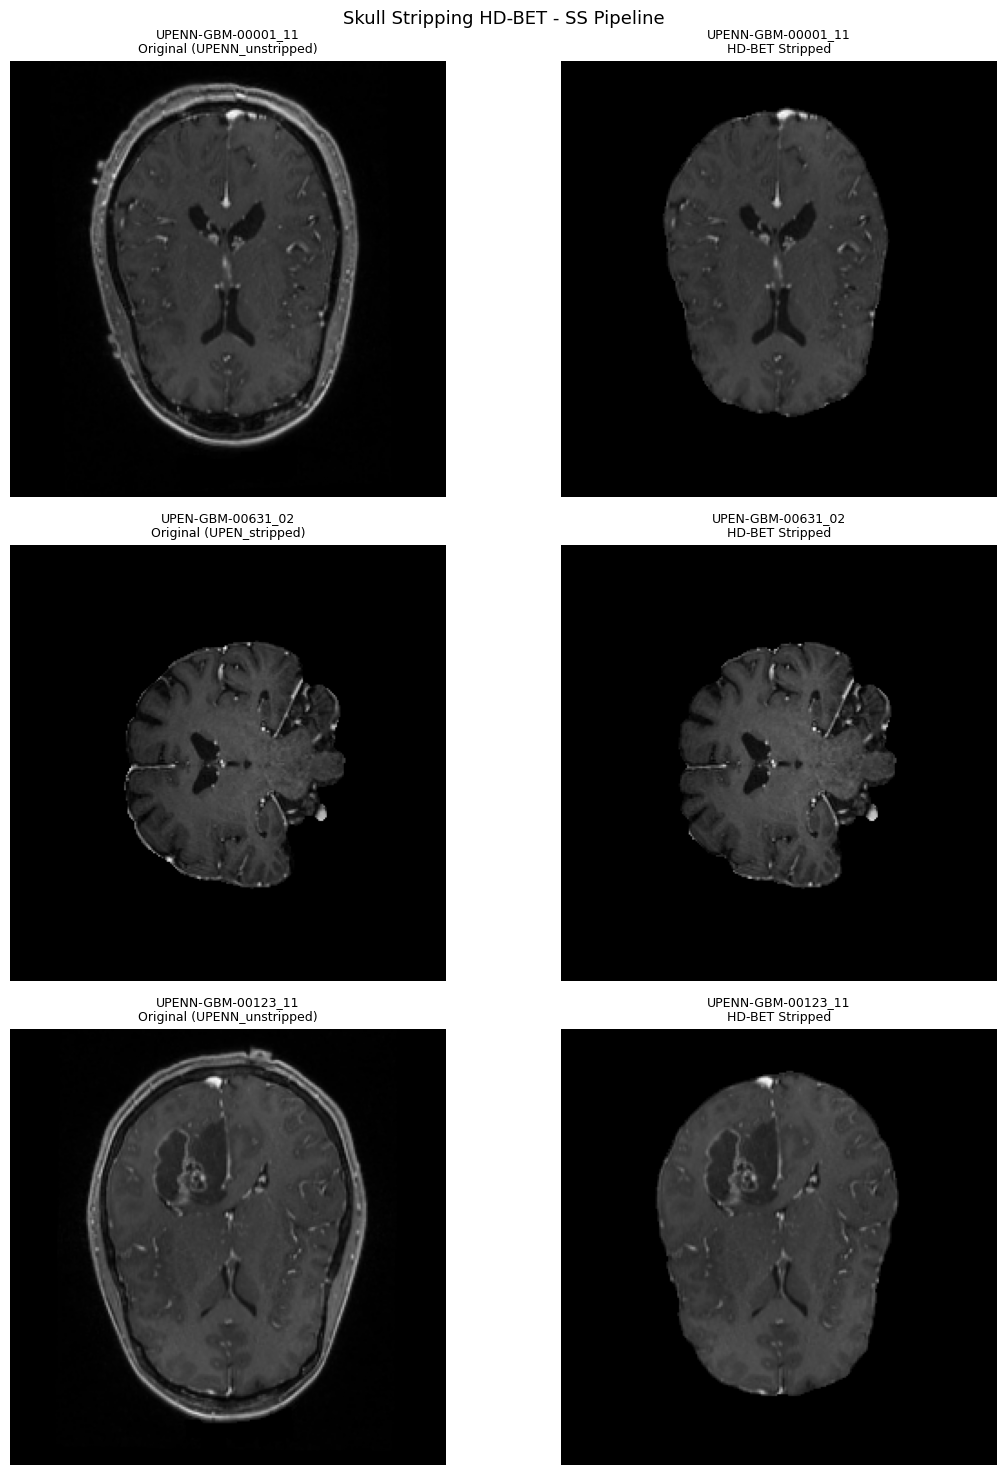

Figura guardada.


In [ ]:
# CELDA 10 - Visualizacion de resultados
# Muestra 3 casos: 1 UPENN, 1 UPEN externo, 1 al azar

import random

df_ok_upenn = df_ok[df_ok['source'] == 'UPENN_unstripped']
df_ok_upen  = df_ok[df_ok['source'] == 'UPEN_stripped']

casos_viz = []
if len(df_ok_upenn) > 0:
    casos_viz.append(df_ok_upenn.iloc[0])
if len(df_ok_upen) > 0:
    casos_viz.append(df_ok_upen.iloc[0])
if len(df_ok) > 2:
    casos_viz.append(df_ok.iloc[random.randint(2, len(df_ok)-1)])

fig, axes = plt.subplots(len(casos_viz), 2, figsize=(12, 5*len(casos_viz)))
if len(casos_viz) == 1:
    axes = [axes]

for i, row in enumerate(casos_viz):
    sid      = row['sid']
    source   = row['source']

    # Imagen stripped
    img_stripped = nib.load(row['t1ce']).get_fdata()
    mid          = img_stripped.shape[2] // 2
    sl_stripped  = img_stripped[:, :, mid]
    sl_norm      = (sl_stripped - sl_stripped.min()) / (sl_stripped.max() - sl_stripped.min() + 1e-8)

    # Imagen original para comparar
    if source == 'UPENN_unstripped':
        orig_path = UNSTRIPPED_DIR / sid / f'{sid}_T1GD_unstripped.nii.gz'
    else:
        orig_path = STRIPPED_DIR / sid / f'{sid}__t1ce.nii.gz'

    img_orig = nib.load(str(orig_path)).get_fdata()
    sl_orig  = img_orig[:, :, mid]
    sl_orig_norm = (sl_orig - sl_orig.min()) / (sl_orig.max() - sl_orig.min() + 1e-8)

    axes[i][0].imshow(sl_orig_norm.T, cmap='gray', origin='lower')
    axes[i][0].set_title(f'{sid}\nOriginal ({source})', fontsize=9)
    axes[i][0].axis('off')

    axes[i][1].imshow(sl_norm.T, cmap='gray', origin='lower')
    axes[i][1].set_title(f'{sid}\nHD-BET Stripped', fontsize=9)
    axes[i][1].axis('off')

plt.suptitle('Skull Stripping HD-BET - SS Pipeline', fontsize=13)
plt.tight_layout()
plt.savefig(SS_FIGURES / 'skull_stripping_samples.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figura guardada.')

In [ ]:
# CELDA 11 - Guardar indice de casos procesados para notebooks siguientes
# Este archivo es la entrada del SS_02_segmentacion.ipynb

index_path = SS_DIR / 'ss_cases_index.csv'
df_ok.to_csv(str(index_path), index=False)

print(f'Indice de casos guardado en: {index_path}')
print(f'Total casos disponibles para SS_02: {len(df_ok)}')
print(f'\nColumnas del indice:')
print(df_ok.columns.tolist())
print(f'\nPrimeros 3 casos:')
print(df_ok[['sid', 'source', 'brain_voxels']].head(3).to_string(index=False))

Indice de casos guardado en: /content/drive/MyDrive/GBM_TESIS/SS_PIPELINE/ss_cases_index.csv
Total casos disponibles para SS_02: 722

Columnas del indice:
['sid', 'source', 'status', 'brain_voxels', 't1', 't1ce', 't2', 'flair', 'error']

Primeros 3 casos:
               sid           source  brain_voxels
UPENN-GBM-00001_11 UPENN_unstripped       1404769
UPENN-GBM-00002_11 UPENN_unstripped       1472599
UPENN-GBM-00003_11 UPENN_unstripped       1636794


In [ ]:
# CELDA FINAL - Guardar pesos HD-BET en Drive para reusar en futuras sesiones
import shutil
from pathlib import Path

hdbet_cache = Path('/root/hd-bet_params')
hdbet_drive = Path('/content/drive/MyDrive/GBM_TESIS/hdbet_weights')

if hdbet_cache.exists() and not hdbet_drive.exists():
    shutil.copytree(str(hdbet_cache), str(hdbet_drive))
    print(f'✅ Pesos guardados en Drive: {hdbet_drive}')
    print('La próxima sesión los cargará en segundos.')
elif hdbet_drive.exists():
    print('✅ Pesos ya estaban guardados en Drive.')
else:
    print('⚠️ No se encontraron pesos en caché para guardar.')


⚠️ No se encontraron pesos en caché para guardar.
